In [1]:
import pandas as pd

In [2]:
df = pd.read_csv('dados_comunidade.csv')

In [3]:
df = df.replace({'Sim': 1, 'Não': 0})

C:\Users\gabri\AppData\Local\Temp\ipykernel_32360\2398527104.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df = df.replace({'Sim': 1, 'Não': 0})


In [75]:
df.head()
df.columns

Index(['Carimbo de data/hora', 'Como conheceu o Téo Me Why?',
       'Quantos cursos acompanhou do Téo Me Why?', 'Curte games?',
       'Curte futebol?', 'Curte livros?', 'Curte jogos de tabuleiro?',
       'Curte jogos de fórmula 1?', 'Curte jogos de MMA?', 'Idade',
       'Estado que mora atualmente', 'Área de Formação',
       'Tempo que atua na área de dados', 'Posição da cadeira (senioridade)',
       'Você se considera uma pessoa feliz?'],
      dtype='object')

In [5]:
num_vars =['Curte games?',	
'Curte futebol?',
'Curte livros?',	
'Curte jogos de tabuleiro?',
'Curte jogos de fórmula 1?',
'Curte jogos de MMA?',	
'Idade']

dummy_vars = ['Como conheceu o Téo Me Why?',
'Quantos cursos acompanhou do Téo Me Why?',
'Estado que mora atualmente',
'Área de Formação',
'Tempo que atua na área de dados',
'Posição da cadeira (senioridade)']
df_analise = pd.get_dummies(df[dummy_vars]).astype(int) # má prática!!
df_analise[num_vars] = df[num_vars].copy()
df_analise

,Como conheceu o Téo Me Why?_Amigos,Como conheceu o Téo Me Why?_Instagram,Como conheceu o Téo Me Why?_LinkedIn,Como conheceu o Téo Me Why?_Outra rede social,Como conheceu o Téo Me Why?_Twitch,Como conheceu o Téo Me Why?_Twitter / X,Como conheceu o Téo Me Why?_YouTube,Quantos cursos acompanhou do Téo Me Why?_0,Quantos cursos acompanhou do Téo Me Why?_1,Quantos cursos acompanhou do Téo Me Why?_2,...,Posição da cadeira (senioridade)_Júnior,Posição da cadeira (senioridade)_Pleno,Posição da cadeira (senioridade)_Sênior,Curte games?,Curte futebol?,Curte livros?,Curte jogos de tabuleiro?,Curte jogos de fórmula 1?,Curte jogos de MMA?,Idade
0,0,0,1,0,0,0,0,1,0,0,...,0,0,1,1,0,1,1,1,0,34
1,0,0,0,0,1,0,0,0,0,0,...,0,0,0,1,1,1,0,0,1,26
2,0,0,0,0,0,0,1,0,0,0,...,1,0,0,1,1,1,1,1,1,39
3,0,0,0,0,0,0,1,0,0,0,...,0,1,0,1,1,1,1,1,0,27
4,0,0,0,0,1,0,0,0,0,1,...,0,1,0,1,1,1,1,0,0,29
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
177,1,0,0,0,0,0,0,0,0,1,...,1,0,0,1,1,1,0,1,0,33
178,0,0,0,0,1,0,0,0,0,0,...,0,0,1,1,1,1,1,1,1,32
179,0,0,0,0,0,1,0,0,1,0,...,0,0,0,1,1,1,1,0,0,39
180,0,0,1,0,0,0,0,0,1,0,...,0,1,0,1,0,1,0,0,0,25


In [15]:
df_analise['pessoa feliz'] = df['Você se considera uma pessoa feliz?'].copy()
df_analise

,Como conheceu o Téo Me Why?_Amigos,Como conheceu o Téo Me Why?_Instagram,Como conheceu o Téo Me Why?_LinkedIn,Como conheceu o Téo Me Why?_Outra rede social,Como conheceu o Téo Me Why?_Twitch,Como conheceu o Téo Me Why?_Twitter / X,Como conheceu o Téo Me Why?_YouTube,Quantos cursos acompanhou do Téo Me Why?_0,Quantos cursos acompanhou do Téo Me Why?_1,Quantos cursos acompanhou do Téo Me Why?_2,...,Posição da cadeira (senioridade)_Pleno,Posição da cadeira (senioridade)_Sênior,Curte games?,Curte futebol?,Curte livros?,Curte jogos de tabuleiro?,Curte jogos de fórmula 1?,Curte jogos de MMA?,Idade,pessoa feliz
0,0,0,1,0,0,0,0,1,0,0,...,0,1,1,0,1,1,1,0,34,1
1,0,0,0,0,1,0,0,0,0,0,...,0,0,1,1,1,0,0,1,26,1
2,0,0,0,0,0,0,1,0,0,0,...,0,0,1,1,1,1,1,1,39,1
3,0,0,0,0,0,0,1,0,0,0,...,1,0,1,1,1,1,1,0,27,1
4,0,0,0,0,1,0,0,0,0,1,...,1,0,1,1,1,1,0,0,29,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
177,1,0,0,0,0,0,0,0,0,1,...,0,0,1,1,1,0,1,0,33,1
178,0,0,0,0,1,0,0,0,0,0,...,0,1,1,1,1,1,1,1,32,1
179,0,0,0,0,0,1,0,0,1,0,...,0,0,1,1,1,1,0,0,39,0
180,0,0,1,0,0,0,0,0,1,0,...,1,0,1,0,1,0,0,0,25,0


In [16]:
features = df_analise.columns[:-1].tolist()
X = df_analise[features]
y = df_analise['pessoa feliz']

In [39]:
from sklearn import tree
from sklearn import naive_bayes
from sklearn import linear_model

In [42]:
reg = linear_model.LogisticRegression(penalty=None, fit_intercept=True)
reg.fit(X, y)

C:\Users\gabri\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,penalty,None
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [18]:
arvore = tree.DecisionTreeClassifier(random_state=42,
                                     min_samples_leaf=5,
                                    )

In [19]:
naive = naive_bayes.GaussianNB()
naive.fit(X, y)

,priors,None
,var_smoothing,1e-09


In [22]:
arvore_predict = arvore.predict(X) 

In [21]:
arvore.fit(X, y)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,5
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [23]:
arvore_predict = arvore.predict(X) #Não se usa o mesmo dado para treinar e predictar
arvore_predict

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1,
       1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1,
       0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0,
       1, 1, 1, 0, 0, 1])

In [43]:
df_predict = df_analise[['pessoa feliz']].copy()
df_predict['predict_arvore'] = arvore_predict
df_predict['proba_arvore'] = arvore.predict_proba(X)[:,1]
df_predict['predict_naive'] = naive.predict(X)
df_predict['proba_naive'] = naive.predict_proba(X)[:,1]
df_predict['predict_reg'] = reg.predict(X)
df_predict['proba_reg'] = reg.predict_proba(X)[:,1]
df_predict

,pessoa feliz,predict_arvore,proba_arvore,predict_naive,proba_naive,predict_reg,proba_reg
0,1,1,0.714286,0,8.579697e-18,1,0.964281
1,1,1,0.750000,0,2.420248e-19,1,0.813870
2,1,1,0.857143,0,3.280598e-10,1,0.999991
3,1,1,0.857143,0,8.082140e-12,1,0.999421
4,1,1,1.000000,1,1.000000e+00,1,0.989343
...,...,...,...,...,...,...,...
177,1,1,0.600000,0,7.470531e-13,1,0.997666
178,1,1,0.600000,1,1.000000e+00,1,0.998154
179,0,0,0.285714,0,3.394327e-20,0,0.495548
180,0,0,0.400000,0,8.266188e-18,1,0.534132


In [25]:
# Acurácia! (as vezes não é suficiente -> não me fala onde estou acertando)
(df_predict['pessoa feliz'] == df_predict['predict_arvore']).mean()

np.float64(0.8626373626373627)

In [26]:
pd.crosstab(df_predict['pessoa feliz'], df_predict['predict_arvore'])

predict_arvore,0,1
pessoa feliz,,
0,16,19
1,6,141


dos 21 `zeros` que meu modelo disse que tinha ele acertou 16 e errou 6
essa é uma maneira de se interpretar essa pequena matriz de confusão

In [27]:
(df_predict['pessoa feliz'] == 1).sum()

np.int64(147)

In [28]:
from sklearn import metrics

In [54]:
acc_arvore = metrics.accuracy_score(df_predict['pessoa feliz'], df_predict['predict_arvore'])
precisao_arvore = metrics.precision_score(df_predict['pessoa feliz'], df_predict['predict_arvore'])
recall_arvore = metrics.recall_score(df_predict['pessoa feliz'], df_predict['predict_arvore'])

acc_naive = metrics.accuracy_score(df_predict['pessoa feliz'], df_predict['predict_naive'])
precisao_naive = metrics.precision_score(df_predict['pessoa feliz'], df_predict['predict_naive'])
recall_naive = metrics.recall_score(df_predict['pessoa feliz'], df_predict['predict_naive'])

acc_reg = metrics.accuracy_score(df_predict['pessoa feliz'], df_predict['predict_reg'])
precisao_reg = metrics.precision_score(df_predict['pessoa feliz'], df_predict['predict_reg'])
recall_reg = metrics.recall_score(df_predict['pessoa feliz'], df_predict['predict_reg'])

In [55]:
# Curva Roc
roc_arvore = metrics.roc_curve(df_predict['pessoa feliz'], df_predict['proba_arvore'])
auc_arvore = metrics.roc_auc_score(df_predict['pessoa feliz'], df_predict['proba_arvore'])

In [56]:
# Curva Roc
roc_naive = metrics.roc_curve(df_predict['pessoa feliz'], df_predict['proba_naive'])
auc_naive = metrics.roc_auc_score(df_predict['pessoa feliz'], df_predict['proba_naive'])

In [57]:
roc_reg = metrics.roc_curve(df_predict['pessoa feliz'], df_predict['proba_reg'])
auc_reg = metrics.roc_auc_score(df_predict['pessoa feliz'], df_predict['proba_reg'])

In [58]:
import matplotlib.pyplot as plt

Text(0.5, 1.0, 'ROC Curve')

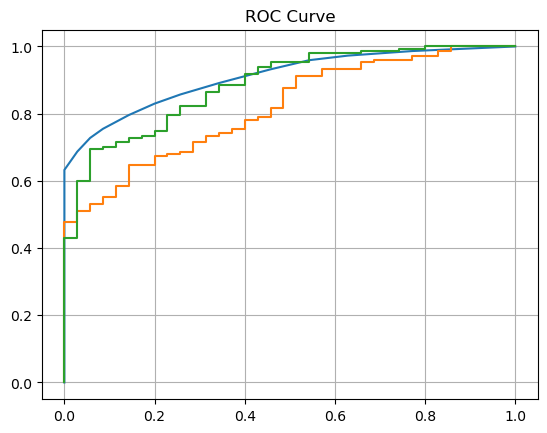

In [59]:
plt.plot(roc_arvore[0], roc_arvore[1])
plt.plot(roc_naive[0], roc_naive[1])
plt.plot(roc_reg[0], roc_reg[1])
plt.grid(True)
plt.title('ROC Curve')

Os dois lados da balança (Os Eixos)
Eixo Vertical (Y - True Positive Rate): É o seu "Sucesso". Ele vai de 0 a 1.0. Se estiver no 1.0, você acertou 100% das Weissbiers que passaram pela máquina.

Eixo Horizontal (X - False Positive Rate): É o seu "Erro de Alarme Falso". Ele também vai de 0 a 1.0. Se estiver no 1.0, você é um "mentiroso" — você disse que todas as cervejas eram Weissbier, inclusive as que não eram.

In [53]:
pd.Series({'model': reg, 'features': features}).to_pickle('model_feliz.pkl')